# **CLASSIFICATION**
**Owner:** Ruth Mutheu

## **Predicting Obesity Levels Based on Eating Habits and Physical Condition**
This project aims to predict the obesity level of individuals based on their eating habits, lifestyle and physical conditions.

The dataset contains 2,111 records with 17 attributes, including numerical, categorical and binary features.  
We also perform exploratory data analysis (EDA), preprocessing and feature selection to optimize model performance. Two classification models, Logistic Regression and Random Forest, are applied to classify obesity levels.


### **Research Question**
Can we accurately predict the obesity level of an individual using their eating habits and physical conditions?

### **Objective**
The objective is to predict obesity level based on the given features.

### **Ethical and Social Considerations**
- *Data privacy:* The dataset is publicly available and anonymized, meaning no personal identifiers are included.
- *Bias and fairness:* Since lifestyle and health data can vary across demographic groups, model performance is evaluated carefully to identify any patterns of bias. This ensures the classifier treats all obesity categories consistently and does not favour or disadvantage specific groups.
- *Avoiding Stigma:* Obesity is a sensitive topic, and predictions should not be used to label, shame, or stigmatise individuals. Any insights derived must be applied in supportive, non-judgmental contexts.


### **Data Extraction**
Let us extract the data directly from the UCI Machine Learning Repository using web scraping.

**Data Source:** https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition

In [1]:
#import libraries
import requests
import zipfile
import io
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


#load dataset
url = 'https://archive.ics.uci.edu/static/public/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition.zip'

#download the zip file
r = requests.get(url)
r.raise_for_status()

#read zip file content
with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    print("File inside zip:", z.namelist())
    
    #extract and read csv file
    with z.open("ObesityDataSet_raw_and_data_sinthetic.csv") as d:
        df = pd.read_csv(d)

#display the first five records
display(df.head())

File inside zip: ['ObesityDataSet_raw_and_data_sinthetic.csv']


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## **Exploratory Data Analysis (EDA)**

### **Dataset Exploration**
Let us now explore the dataset features to understand its structure. To enhance clarity and consistency throughout the analysis, the column names were renamed to more descriptive column names. 

We then examine the data structure, column types, null values and basic statistics for each variable.

In [2]:
#column names meaning

# Gender-Gender
# Age-Age
# Height-Height
# Weight-Weight
# Family_history_with_overweight-Family history with overweight
# FAVC-Frequent consumption of high calorie food
# FCVC-Consumption of vegetables
# NCP-Number of daily main meals
# CAEC-Consumption of food between meals
# Smoke-Smoke
# CH2O-Daily consumption of water
# SCC-Daily Calorie Monitoring
# FAF-Frequency of Physical activity
# TUE-Time spent using technological devices
# CALC-Consumption of alcohol
# MTRANS-Transportation used
# NObeyesdad-Obesity level

In [3]:
#define a mapping of original column names to descriptive names
column_mapping = {
    "Gender": "Gender",
    "Age": "Age",
    "Height": "Height",
    "Weight": "Weight",
    "family_history_with_overweight": "Family_History_Overweight",
    "FAVC": "Frequent_HighCalorie_Food",
    "FCVC": "Vegetable_Consumption",
    "NCP": "Daily_Main_Meals",
    "CAEC": "Food_Between_Meals",
    "SMOKE": "Smoke",
    "CH2O": "Water_Intake",
    "SCC": "Daily_Calorie_Monitoring",
    "FAF": "Physical_Activity_Frequency",
    "TUE": "Time_Using_Devices",
    "CALC": "Alcohol_Consumption",
    "MTRANS": "Transportation",
    "NObeyesdad": "Obesity_Level"
}

#rename columns
df.rename(columns=column_mapping, inplace=True)

#check the new column names
print(df.columns)


Index(['Gender', 'Age', 'Height', 'Weight', 'Family_History_Overweight',
       'Frequent_HighCalorie_Food', 'Vegetable_Consumption',
       'Daily_Main_Meals', 'Food_Between_Meals', 'Smoke', 'Water_Intake',
       'Daily_Calorie_Monitoring', 'Physical_Activity_Frequency',
       'Time_Using_Devices', 'Alcohol_Consumption', 'Transportation',
       'Obesity_Level'],
      dtype='object')


In [4]:
#check for duplicate rows
df.duplicated().sum()

24

In [5]:
#drop duplicate rows
df = df.drop_duplicates()

In [6]:
#check the last five records
df.tail()

,Gender,Age,Height,Weight,Family_History_Overweight,Frequent_HighCalorie_Food,Vegetable_Consumption,Daily_Main_Meals,Food_Between_Meals,Smoke,Water_Intake,Daily_Calorie_Monitoring,Physical_Activity_Frequency,Time_Using_Devices,Alcohol_Consumption,Transportation,Obesity_Level
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III
2110,Female,23.664709,1.738836,133.472641,yes,yes,3.0,3.0,Sometimes,no,2.863513,no,1.026452,0.714137,Sometimes,Public_Transportation,Obesity_Type_III


In [7]:
#overview of the dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       2087 non-null   object 
 1   Age                          2087 non-null   float64
 2   Height                       2087 non-null   float64
 3   Weight                       2087 non-null   float64
 4   Family_History_Overweight    2087 non-null   object 
 5   Frequent_HighCalorie_Food    2087 non-null   object 
 6   Vegetable_Consumption        2087 non-null   float64
 7   Daily_Main_Meals             2087 non-null   float64
 8   Food_Between_Meals           2087 non-null   object 
 9   Smoke                        2087 non-null   object 
 10  Water_Intake                 2087 non-null   float64
 11  Daily_Calorie_Monitoring     2087 non-null   object 
 12  Physical_Activity_Frequency  2087 non-null   float64
 13  Time_Using_Devices     

In [8]:
#check variable data types
df.dtypes

Gender                          object
Age                            float64
Height                         float64
Weight                         float64
Family_History_Overweight       object
Frequent_HighCalorie_Food       object
Vegetable_Consumption          float64
Daily_Main_Meals               float64
Food_Between_Meals              object
Smoke                           object
Water_Intake                   float64
Daily_Calorie_Monitoring        object
Physical_Activity_Frequency    float64
Time_Using_Devices             float64
Alcohol_Consumption             object
Transportation                  object
Obesity_Level                   object
dtype: object

In [9]:
#check dimensions of the dataset
df.shape

(2087, 17)

### **Identification of Variable Types and Summary Statistics**
The dataset contains both numerical and categorical features. Separating these types allows us to apply appropriate preprocessing techniques for each. We also summarize descriptive statistics for numerical variables and frequency counts for categorical variables to better understand the data distribution.

We omit the target variable 'Obesity_Level' while summarizing features as it is not an input variable.

In [10]:
#describe numerical features
num_cols = ['Age',
            'Height',
            'Weight',
            'Vegetable_Consumption',
            'Daily_Main_Meals',
            'Water_Intake',
            'Physical_Activity_Frequency',
            'Time_Using_Devices'
           ]

#summary statistics
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2087.0,24.353090,6.368801,14.00,19.915937,22.847618,26.000000,61.00
Height,2087.0,1.702674,0.093186,1.45,1.630178,1.701584,1.769491,1.98
Weight,2087.0,86.858730,26.190847,39.00,66.000000,83.101100,108.015907,173.00
Vegetable_Consumption,2087.0,2.421466,0.534737,1.00,2.000000,2.396265,3.000000,3.00
Daily_Main_Meals,2087.0,2.701179,0.764614,1.00,2.697467,3.000000,3.000000,4.00
Water_Intake,2087.0,2.004749,0.608284,1.00,1.590922,2.000000,2.466193,3.00
Physical_Activity_Frequency,2087.0,1.012812,0.853475,0.00,0.124505,1.000000,1.678102,3.00
Time_Using_Devices,2087.0,0.663035,0.608153,0.00,0.000000,0.630866,1.000000,2.00


In [11]:
#describe categorical features
cat_cols = ['Gender',
            'Family_History_Overweight',
            'Frequent_HighCalorie_Food',
            'Food_Between_Meals',
            'Smoke',
            'Daily_Calorie_Monitoring',
            'Alcohol_Consumption',
            'Transportation']

#summary statistics
df[cat_cols].describe().T

,count,unique,top,freq
Gender,2087,2,Male,1052
Family_History_Overweight,2087,2,yes,1722
Frequent_HighCalorie_Food,2087,2,yes,1844
Food_Between_Meals,2087,4,Sometimes,1761
Smoke,2087,2,no,2043
Daily_Calorie_Monitoring,2087,2,no,1991
Alcohol_Consumption,2087,4,Sometimes,1380
Transportation,2087,5,Public_Transportation,1558


In [12]:
#target variable distribution
df['Obesity_Level'].value_counts()

Obesity_Level
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     276
Insufficient_Weight    267
Name: count, dtype: int64

#### **Result Interpretation**
From the output above, the target variable (Obesity_Level) has seven classes. Its distribution shows no extreme imbalance, so class balancing is not necessary.

### **Exploring the Data Graphically**
Now let us explore the data graphically to visually understand patterns, distributions and relationships in our dataset.

#### **Distribution of Categorical Features by Gender**
This visual allows us to compare how different categories vary between males and females.

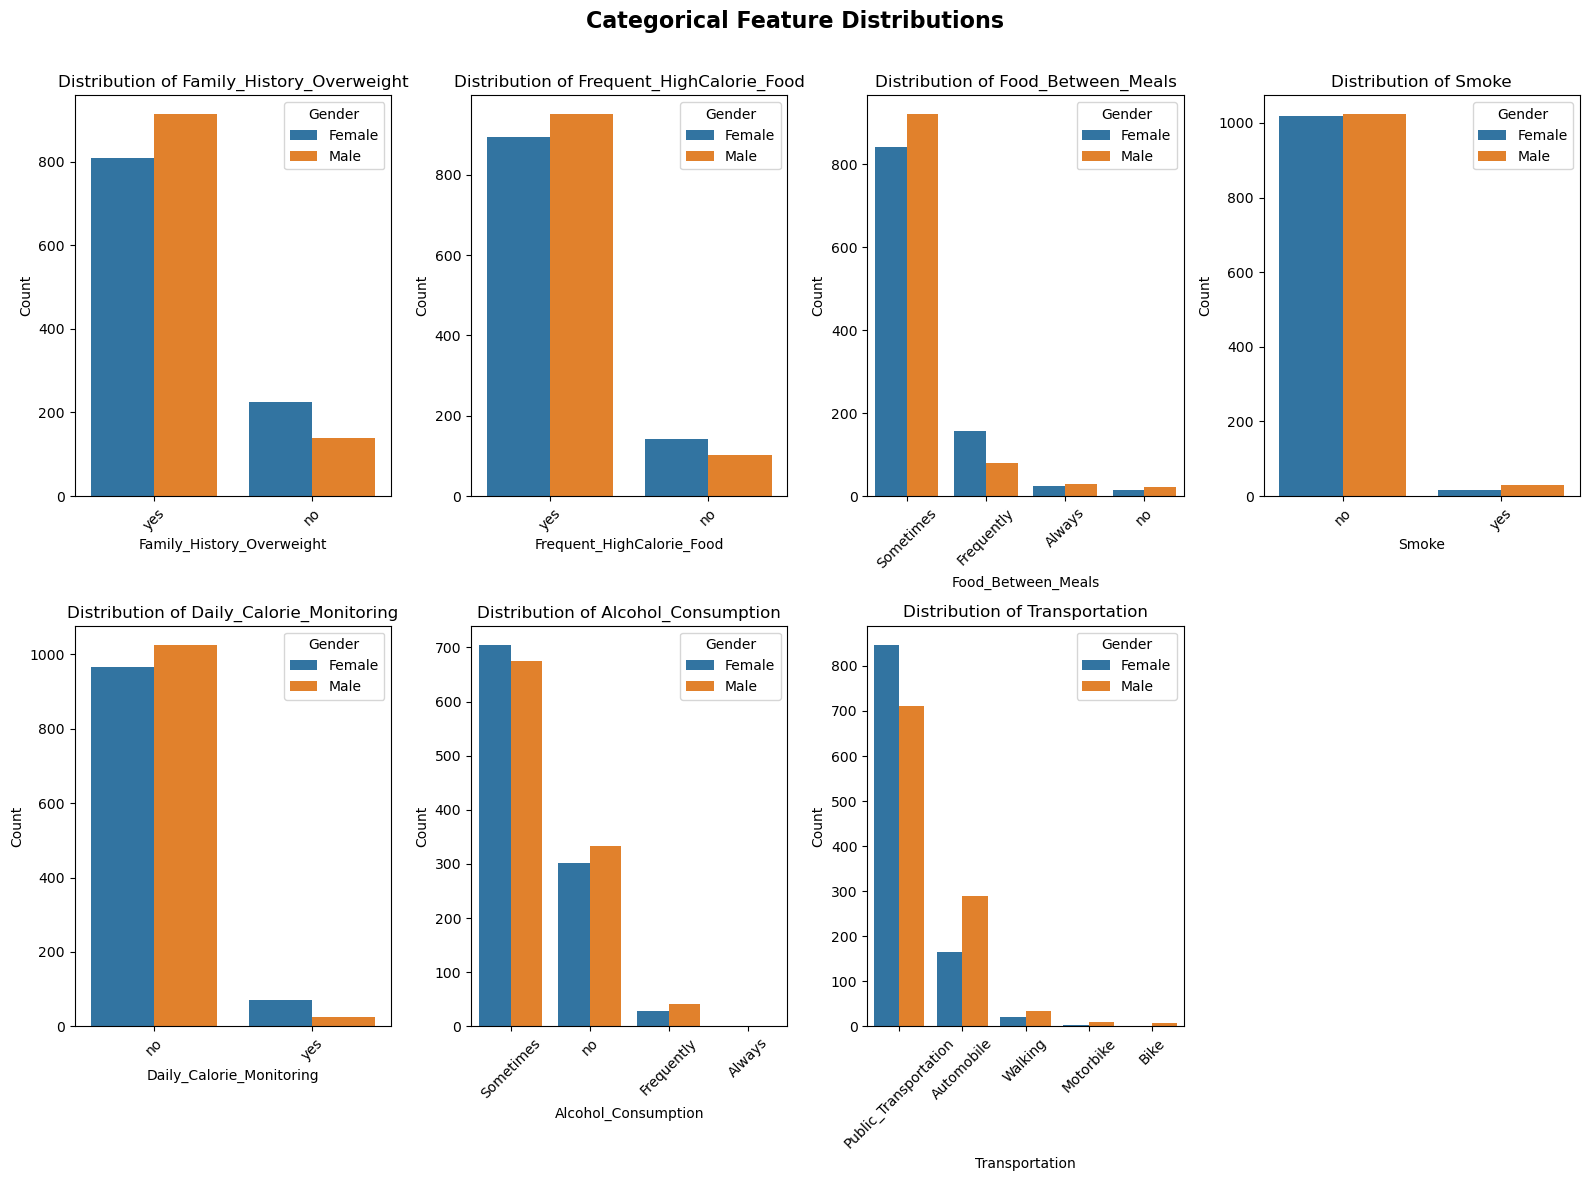

In [13]:
#exclude gender from categorical feature plot
cat_cols_no_gender = [col for col in cat_cols if col != 'Gender']

#visualize categorical feature distributions
plt.figure(figsize=(16, 12))

for i, col in enumerate(cat_cols_no_gender):
    plt.subplot(2, 4, i + 1)
    sns.countplot(x=col, data=df, hue='Gender', order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}", fontsize=12)
    plt.xticks(rotation=45)
    plt.ylabel("Count")
    plt.xlabel(col)

plt.suptitle("Categorical Feature Distributions", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


##### **Result Interpretation**
- A large proportion of both males and females have a family history of being overweight, with males slightly exceeding females.
- Many individuals of both genders frequently consume high-calorie foods, with men reporting slightly higher intake than women.
- Most participants, regardless of gender, do not smoke.
- Very few people actively monitor their daily calorie intake.
- Most individuals sometimes consume alcohol with women slightly exceeding men.
- Public transportation is the most commonly used mode of transport, with women using it more than men.

#### **Correlation Heatmap**
Let us now check the relationship between numerical features. This helps us identify which variables are strongly, either positively or negatively, related to each other.

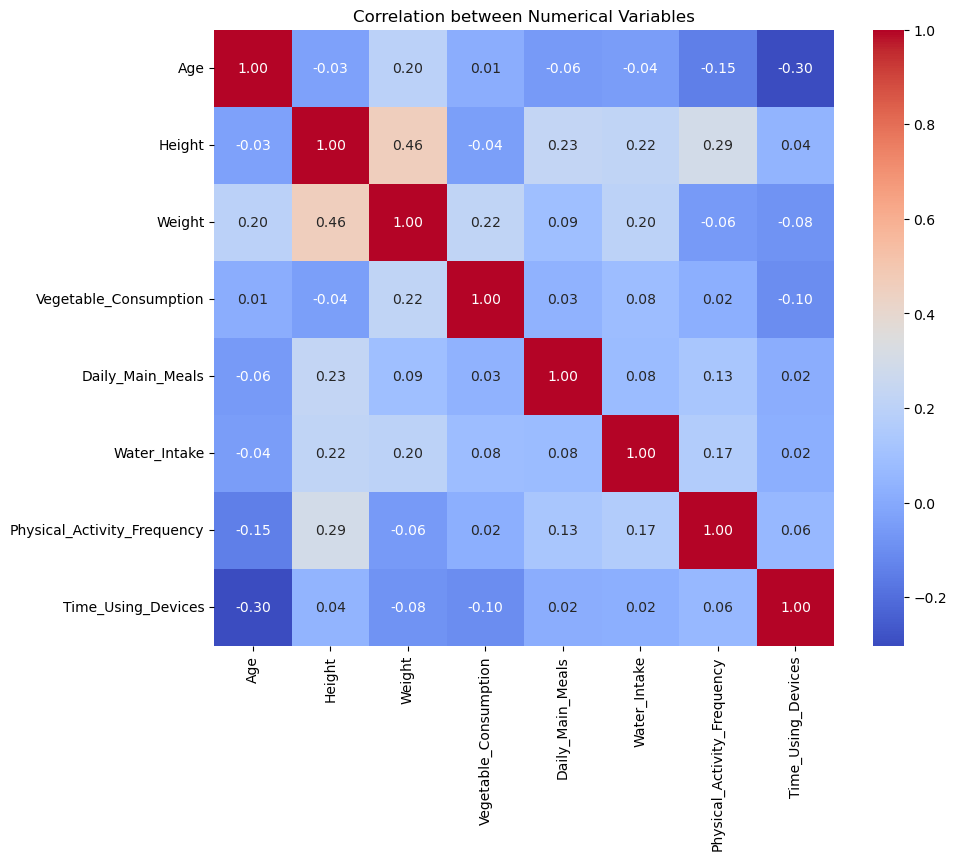

In [14]:
#correlation heatmap for numerical variables
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation between Numerical Variables")
plt.show()

##### **Result Interpretation**
From the correlation heatmap above, most numerical variables show moderate to weak correlations indicating that each contributes unique information about an individual's characteristics related to obesity risk

#### **Distribution of Numerical Features**
Next, we plot histograms and density curves to visualize the distribution of the numerical variables in the dataset.

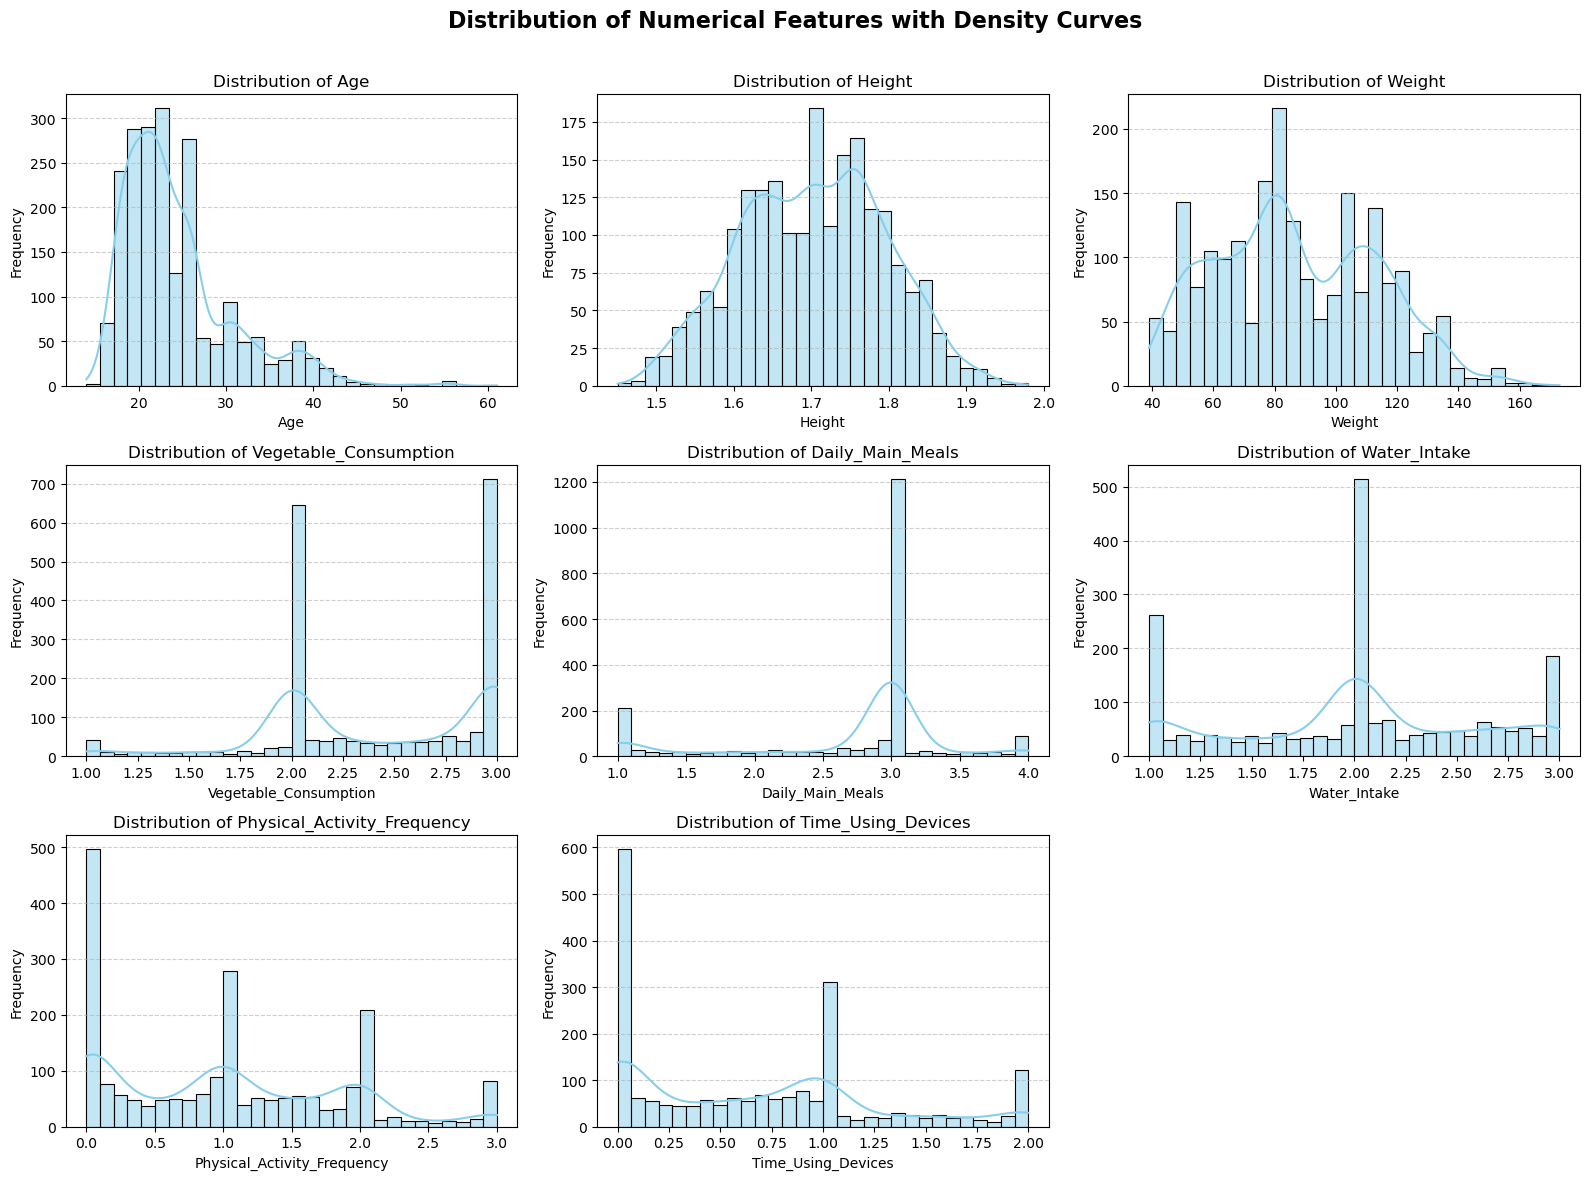

In [15]:
#visualize numeric feature distributions
plt.figure(figsize=(16, 12))

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], bins=30, kde=True, color='skyblue', edgecolor='black')
    plt.title(f"Distribution of {col}", fontsize=12)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle("Distribution of Numerical Features with Density Curves", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


##### **Result Interpretation**
From the visuals, most variables like age, height and weight appear to follow an approximately normal or slightly skewed distributions while others like physical activity frequency and time using devices are more unevenly distributed.

#### **Detection of Outliers**
Here, boxplots were used to identify potential outliers within the numerical features. This will provide a clear view of the data spread and highlights of any extreme values.

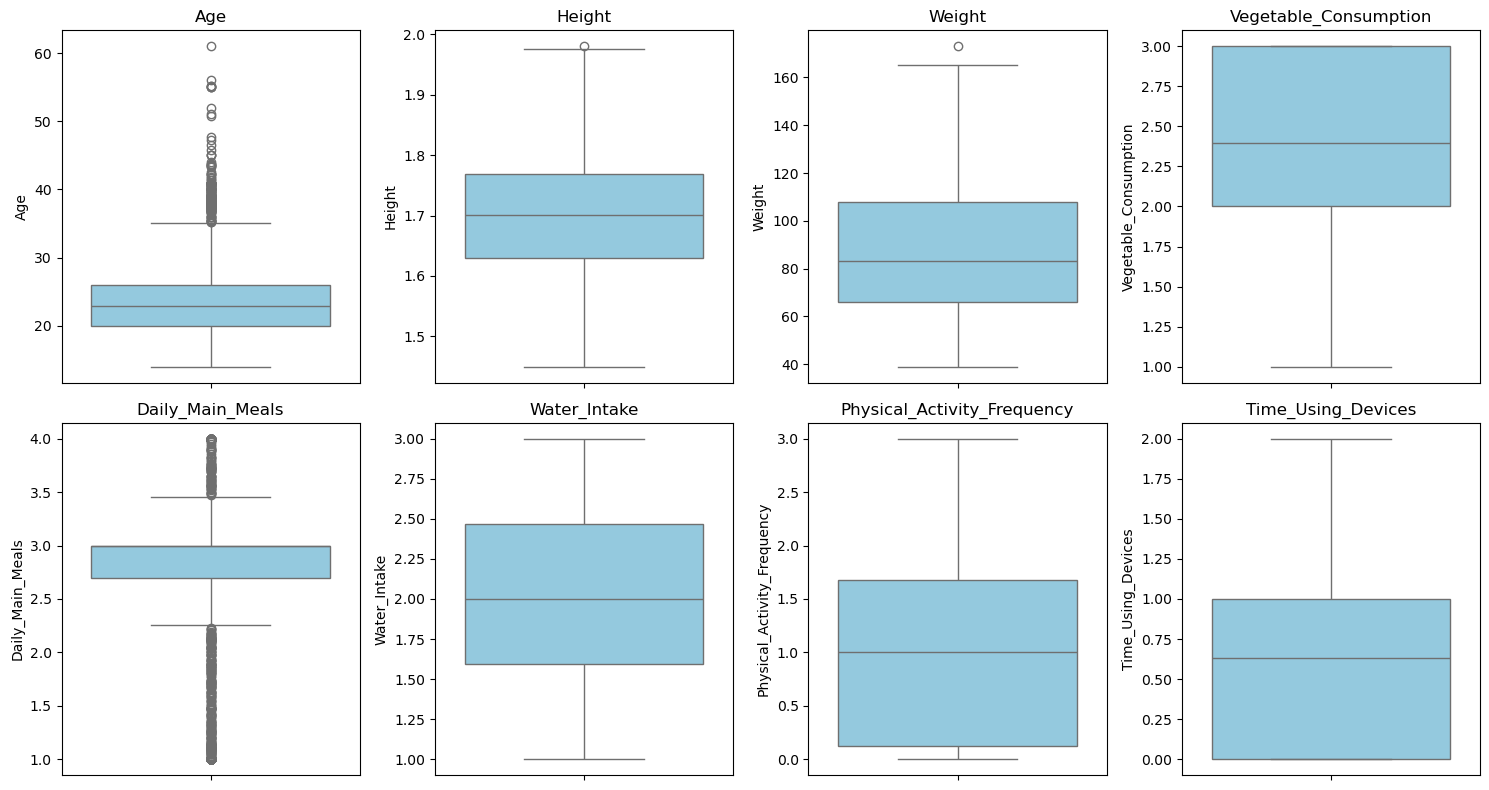

In [16]:
#check for outliers using boxplots
plt.figure(figsize=(15,8))
for i, col in enumerate(num_cols):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()

##### **Result Interpretation**
From the plots, we can draw below conclusions:
- Age has multiple outliers above the third quartile indicating a few individuals who significantly older than the majority of the dataset.
- Weight and Height each have a single outlier above the third quartile, suggesting one unusually heavy individual and one unusually tall individual.
- Daily_Main_Meals exhibits several outliers both below the first quartile and above the third quartile reflecting individuals with unusually few or many daily meals.
- The remaining numerical features, Vegetable_Consumption, Water_Intake, Physical_Activity_Frequency and Time_Using_Devices show no significant outliers.

#### **Target Variable Distribution**
Lets now plot a count plot to visualize the number of instances in each class. 

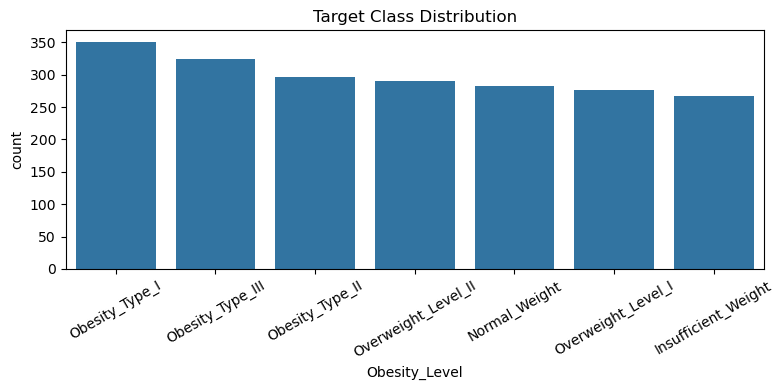

In [17]:
#checking target variable distribution
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Obesity_Level', order=df['Obesity_Level'].value_counts().index)
plt.xticks(rotation=30)
plt.title("Target Class Distribution")
plt.tight_layout()
plt.show()

##### **Result Interpretation**
From the plot, we observe that the dataset is relatively balanced across the seven obesity classes:
- Obesity_Type_I has the highest count while Insufficient_Weight has the lowest.
- The distribution indicates there is no extreme class imbalance, which is favorable for training our classification models as it reduces the risk of the model being biased toward any particular class.

## **Data Preprocessing**
Before applying machine learning models, several preprocessing steps need to be performed to prepare the data for analysis.

### **Handling Outliers**
We need to deal with outliers in numerical features as seen in the boxplots plotted above. Age, Weight, Height and daily main meals contained extreme values that could potentially distort the model training.

To address this, we used the interquartile range to detect and cap outliers. We identified unusually low and high values in the features and instead of removing these extreme values, we replaced them with the nearest reasonable value within the normal range of the data. Any value that was much smaller than most of the data was increased to the lowest normal value and any value that was much larger than most of the data was reduced to the highest normal value.

In [18]:
#cap outliers
iqr_features = ['Age', 'Height', 'Weight', 'Daily_Main_Meals']

Q1 = df[iqr_features].quantile(0.25)
Q3 = df[iqr_features].quantile(0.75)
IQR = Q3-Q1

for col in iqr_features:
    lower = Q1[col] - 1.5*IQR[col]
    upper = Q3[col] + 1.5*IQR[col]

#cap values
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

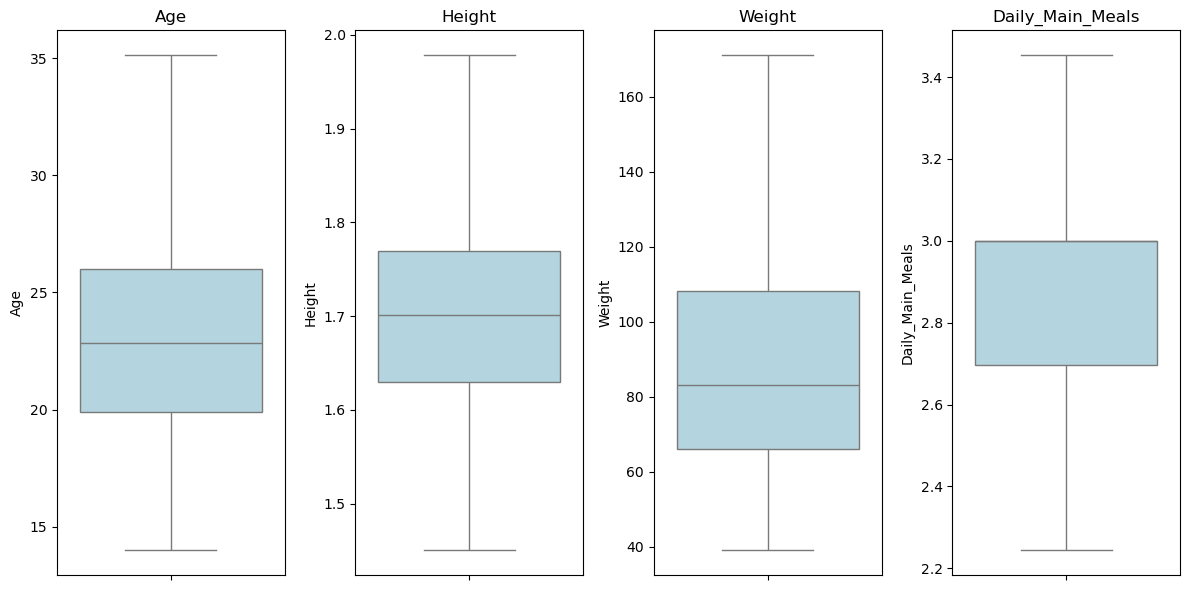

In [19]:
#check if outliers were handled
plt.figure(figsize=(12,6))
for i, col in enumerate(iqr_features):
    plt.subplot(1, len(iqr_features), i+1)
    sns.boxplot(y=df[col], color='lightblue')
    plt.title(col)
plt.tight_layout()
plt.show()

#### **Result Interpretation**
After capping the outliers, we visualize age, height, weight and daily main meals variables again using boxplots to confirm that the previously identified outliers have been properly adjusted.

### **Encode the Target Variable**
The target variable, Obesity_Level, is categorical with string labels representing different obesity categories. Machine learning models require numerical values as targets, so we use _LabelEncoder_ to convert each category into a unique integer code.

In [20]:
#encode target variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['target'] = le.fit_transform(df['Obesity_Level'])

mapping_list= list(zip(le.classes_, le.transform(le.classes_)))

for cls, code in mapping_list:
    print(f"{cls} - {code}")

Insufficient_Weight - 0
Normal_Weight - 1
Obesity_Type_I - 2
Obesity_Type_II - 3
Obesity_Type_III - 4
Overweight_Level_I - 5
Overweight_Level_II - 6


In [21]:
df

,Gender,Age,Height,Weight,Family_History_Overweight,Frequent_HighCalorie_Food,Vegetable_Consumption,Daily_Main_Meals,Food_Between_Meals,Smoke,Water_Intake,Daily_Calorie_Monitoring,Physical_Activity_Frequency,Time_Using_Devices,Alcohol_Consumption,Transportation,Obesity_Level,target
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.000000,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight,1
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.000000,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight,1
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.000000,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight,1
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.000000,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I,5
4,Male,22.000000,1.780000,89.800000,no,no,2.0,2.243667,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.000000,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III,4
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.000000,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III,4
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.000000,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III,4
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.000000,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III,4


### **Define Input and Target Variables**
Here, Obesity_Level is the class label or dependent variable that we want to predict. All other columns except our target variable are independent variables or input features. For classification, our goal is to predict obesity levels (y) of an individual based on their personal, dietary and lifestyle features (X). 

The first step is to separate the data into input features (X) and target variable (y). This ensures that the model knows which data to use for learning patterns and which column to predict

In [22]:
#determining the class feature and target feature
X = df.drop(columns=['Obesity_Level', 'target'])
y = df['target']

### **Split the dataset into Training Set and Test Set**
To evaluate the performance of our models, we split the dataset into a training set and a test set. The training set is used to train the model, while the test set is used to assess how well the model generalizes to unseen data.

We use an 80:20 split, meaning that 80% of the data is for training and 20% for testing. The _stratify=y_ parameter ensures that the class distribution in the target variable is preserved in both the training and test sets. Setting a _random_state_ ensures that the split is reproducible.

In [23]:
#splitting the dataset into Training set and Test set
from sklearn.model_selection import train_test_split

#stratify to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

### **Feature Scaling and Encoding**
Now to ensure that all features are in a suitable format, numerical features need to be scaled using _StandardScaler_ to standardize them bringing all values to a similar range with mean of 0 and standard deviation of 1. This is done to prevent features with large magnitudes from dominating the model.

On the other side, we transform categorical features using _OneHotEncoder_ to convert each category into a binary column. This allows our model to process categorical data effectively as most machine learning algorithms cannot handle non-numeric inputs directly.

In [24]:
#scaling features and encoding categorical features
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

### **Preprocessing Training and Test Sets**
Lets now apply the preprocessing pipeline to scale numeric features and encode categorical ones. The training set is fit and transformed, while the test set is only transformed using the same parameters to ensure consistency and avoid data leakage.

In [25]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

### **Feature Selection with SelectKBest**
The next step is to use SelectKBest to identify the most important features for predicting obesity levels.

To determine the optimal number of features (k), we iterate over a range of possible values. For each k, we:
- Select the top k features from the training data.
- Train a Logistic Regression model using only these features.
- Evaluate its accuracy on the test set.

The k that gives the highest accuracy indicates the optimal number of features for the model.

In [26]:
#tune k to find optimal number of features
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif

k_values = range(5, 25)
acc_scores = []

for k in k_values:
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_fs = selector.fit_transform(X_train_transformed, y_train)
    X_test_fs = selector.transform(X_test_transformed)

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_fs, y_train)
    y_pred = model.predict(X_test_fs)
    acc = accuracy_score(y_test, y_pred)
    acc_scores.append(acc)

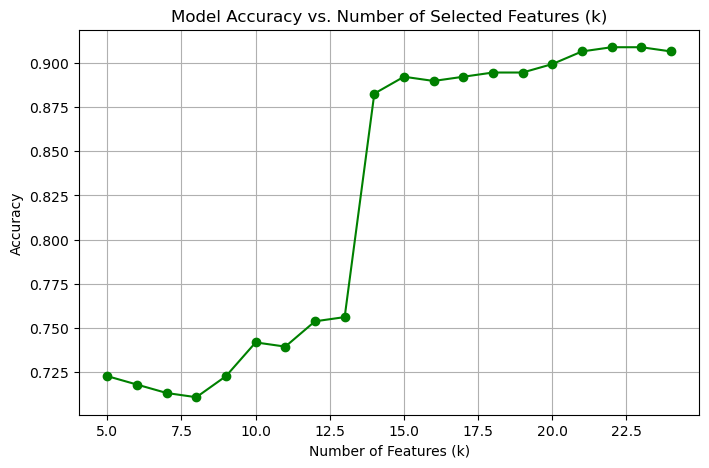

In [27]:
#plot accuracy vs k features
plt.figure(figsize=(8, 5))
plt.plot(k_values, acc_scores, marker='o', color='green')
plt.title("Model Accuracy vs. Number of Selected Features (k)")
plt.xlabel("Number of Features (k)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

#### **Result Interpretation**
The plot above shows how model accuracy changes as we vary the number of selected k features. It helps us visually identify the optimal number of features that maximizes accuracy while avoiding unnecessary features.

In [28]:
#choose best k
best_k = k_values[np.argmax(acc_scores)]
print(f"Optimal number of features (k): {best_k}")

Optimal number of features (k): 22


#### **Result Interpretation**
From the experiment, the highest model accuracy was achieved when using 22 features. This means that out of all available features, these 22 contribute the most to predicting obesity level.

### **Applying Feature Selection with SelectKBest**
After identifying the optimal number of features as 22, we apply SelectKBest to retain only the most important features.

This step transforms both the training and test sets to include only these selected features.

In [29]:
#apply SelectKBest with best_k
selector = SelectKBest(score_func=f_classif, k=best_k)
X_train_fs = selector.fit_transform(X_train_transformed, y_train)
X_test_fs = selector.transform(X_test_transformed)

### **Inspecting Selected and Dropped Features**

In [30]:
#get feature names after encoding
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_features = np.concatenate([num_cols, cat_features])

#selected and dropped features
selected_features = all_features[selector.get_support()]
dropped_features = all_features[~(selector.get_support())]

print("\nSelected Features:\n", selected_features)
print("\nDropped Features:\n", dropped_features)


Selected Features:
 ['Age' 'Height' 'Weight' 'Vegetable_Consumption' 'Daily_Main_Meals'
 'Water_Intake' 'Physical_Activity_Frequency' 'Gender_Female'
 'Gender_Male' 'Family_History_Overweight_no'
 'Family_History_Overweight_yes' 'Frequent_HighCalorie_Food_no'
 'Frequent_HighCalorie_Food_yes' 'Food_Between_Meals_Always'
 'Food_Between_Meals_Frequently' 'Food_Between_Meals_Sometimes'
 'Daily_Calorie_Monitoring_no' 'Daily_Calorie_Monitoring_yes'
 'Alcohol_Consumption_Sometimes' 'Alcohol_Consumption_no'
 'Transportation_Automobile' 'Transportation_Public_Transportation']

Dropped Features:
 ['Time_Using_Devices' 'Food_Between_Meals_no' 'Smoke_no' 'Smoke_yes'
 'Alcohol_Consumption_Always' 'Alcohol_Consumption_Frequently'
 'Transportation_Bike' 'Transportation_Motorbike' 'Transportation_Walking']


### **View the Transformed Training Data**
Lets convert the transformed training data into a pandas DataFrame to inspect and understand the resulting feature structure after applying scaling and one hot encoding on the numerical and categorical variables respectively.

In [31]:
#dataframe from transformed training data
X_train_df = pd.DataFrame(X_train_transformed, columns=all_features)
X_train_df.head()

,Age,Height,Weight,Vegetable_Consumption,Daily_Main_Meals,Water_Intake,Physical_Activity_Frequency,Time_Using_Devices,Gender_Female,Gender_Male,...,Daily_Calorie_Monitoring_yes,Alcohol_Consumption_Always,Alcohol_Consumption_Frequently,Alcohol_Consumption_Sometimes,Alcohol_Consumption_no,Transportation_Automobile,Transportation_Bike,Transportation_Motorbike,Transportation_Public_Transportation,Transportation_Walking
0,0.374776,0.705567,1.045026,-0.375885,0.404932,0.253102,0.308538,-0.452916,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.290525,-0.608075,0.505277,1.016483,-1.703807,-1.644954,0.823971,-0.073903,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,2.136956,0.457523,-0.078269,0.207948,0.404932,-1.403908,-0.827757,-1.095082,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,-0.175296,0.416504,-1.265285,-0.345947,0.404932,-0.252848,1.731352,0.245475,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,-0.554578,-1.012232,-0.725998,-0.801583,0.840739,1.643643,0.204484,-0.952112,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


From the output, it is clear that all features are now in a consistent numerical form ready for the model training.

## **Model Training and Evaluation**
In this stage, the dataset will be used to train two classification models i.e Logistic Regression and Random Forest Classifier with the objective of predicting an individual's obesity level based on the input features.

### **Logistic Regression**
Logistic Regression was chosen because it performs well on multiclass classification problems and provides interpretable coefficients that show how each feature contributes to the prediction.

#### **Model Training**
Lets train the logistic regression model using the selected features to learn the relationship between lifestyle factors and obesity levels. The _multinomial_ setting is used for multiclass prediction and the _lbfgs_ solver ensures efficient optimization of the loss function for multiclass problems.

In [32]:
#initiate the model
log_reg = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs',
                             random_state=42)

#fit data into selected features
log_reg.fit(X_train_fs, y_train)

C:\Users\HP 1040 X360 G5\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

#### **Model Evaluation**
After training the Logistic Regression model, let's evaluate its performance on the test set to assess how well it generalizes to unseen data.

Accuracy Score: 0.9090909090909091
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96        53
           1       0.84      0.81      0.82        57
           2       0.93      0.93      0.93        70
           3       0.94      1.00      0.97        60
           4       1.00      0.98      0.99        65
           5       0.84      0.84      0.84        55
           6       0.87      0.79      0.83        58

    accuracy                           0.91       418
   macro avg       0.91      0.91      0.91       418
weighted avg       0.91      0.91      0.91       418



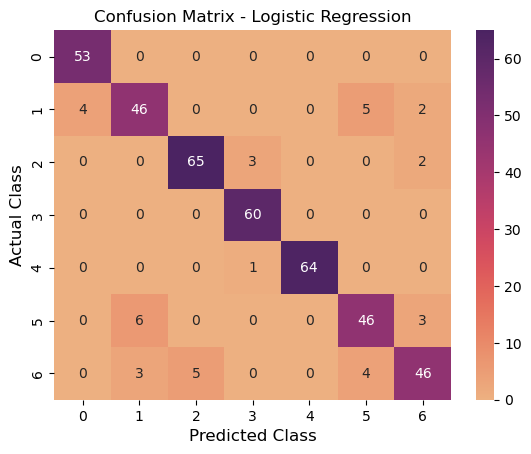

In [33]:
#make predictions on test data
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_lr = log_reg.predict(X_test_fs)

#evaluate performance
print("Accuracy Score:", accuracy_score(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

cm = confusion_matrix(y_test, y_pred_lr)

ax = sns.heatmap(cm, cmap='flare',annot=True, fmt='d')

plt.xlabel("Predicted Class",fontsize=12)
plt.ylabel("Actual Class",fontsize=12)
plt.title("Confusion Matrix - Logistic Regression",fontsize=12)
plt.show()

#### **Interpretation of Logistic Regression Results**
- The Logistic Regression model achieved an accuracy of approximately *91%*, indicating strong predictive performance on unseen data.
- The classification report shows high precision, recall and F1-scores across all obesity categories, demonstrating that the model effectively distinguishes between different obesity levels. 
- Notably, classes such as Obesity_Type_III (4) and Obesity_Type_II (3) achieved nearly perfect scores, reflecting minimal misclassification.

Overall, these results suggest that the Logistic Regression model generalizes well and provides reliable predictions for obesity level classification.


#### **Confusion matrix**
It shows the distribution of predicted versus actual classes. Most predictions are correct as seen along the diagonal, indicating good overall performance. Some misclassifications occur between similar classes eg Class 1 (Normal_Weight) is occasionally predicted as Class 5 (Overweight_Level_I) and Class 6 (Overweight_Level_II) has a few instances misclassified into Classes 2 (Obesity_Type_I) and 5 (Overweight_Level_I). Class 2 (Obesity_Type_I) also shows minor confusion with neighboring classes.

Overall, the matrix demonstrates that the Logistic Regression model performs well across most obesity levels but struggles slightly with classes that have subtle difference

### **Random Forest Classifier**
This model was selected because it is a robust and versatile ensemble learning algorithm that performs well on complex datasets. It combines multiple decision trees to make predictions, reducing the risk of overfitting and improving generalization.

#### **Model Training**
Lets train a Random Forest Classifier on the selected features of the training data. In this model, we used 200 trees (n_estimators=200) to balance performance and computational efficiency, set random_state=42 for reproducibility and enable parallel computation (n_jobs=-1) to speed up training.

This approach allows the model to capture complex relationships between the input features and the target obesity levels, providing a complementary perspective to the Logistic Regression model.

In [34]:
#initialize the model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

#train the model
rf.fit(X_train_fs, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

#### **Model Evaluation**
After training the model, let's evaluate its performance on the test set to see how well it generalizes to unseen data.

Accuracy Score: 0.9401913875598086
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97        53
           1       0.82      0.93      0.87        57
           2       1.00      0.96      0.98        70
           3       0.98      1.00      0.99        60
           4       1.00      0.98      0.99        65
           5       0.87      0.84      0.85        55
           6       0.91      0.91      0.91        58

    accuracy                           0.94       418
   macro avg       0.94      0.94      0.94       418
weighted avg       0.94      0.94      0.94       418



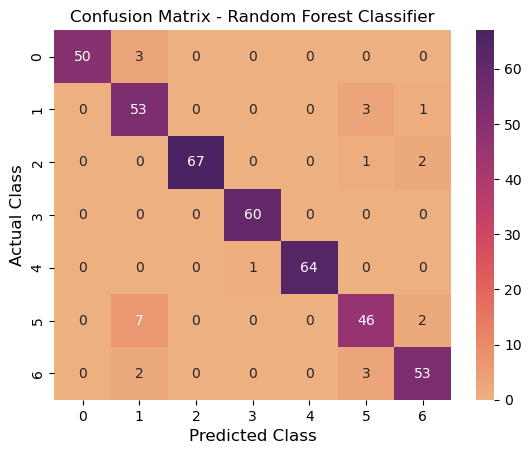

In [35]:
#make predictions on test data
y_pred_rf = rf.predict(X_test_fs)

#evaluate performance
print("Accuracy Score:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)

ax = sns.heatmap(cm, cmap='flare',annot=True, fmt='d')

plt.xlabel("Predicted Class",fontsize=12)
plt.ylabel("Actual Class",fontsize=12)
plt.title("Confusion Matrix - Random Forest Classifier",fontsize=12)
plt.show()

#### **Interpretation of Random Forest Classifier Results**
The Random Forest Classifier achieves an accuracy of *94%* on the test data, indicating strong overall predictive performance.

Examining the classification report, we observe high precision, recall and F1-scores across most obesity categories. Classes such as Obesity_Type_I, Obesity_Type_II and Obesity_Type_III are predicted almost perfectly, while smaller classes like Normal_Weight and Overweight_Level_I/II have slightly lower precision and recall but still perform well.


#### **Confusion matrix**
It shows that most classes are correctly predicted along the diagonal, indicating strong model performance. Minor misclassifications occur between similar or adjacent classes, such as Class 1 (Normal_Weight) having a few instances predicted as Class 5 (Overweight_Level_I) and Class 5 (Overweight_Level_I) having some instances predicted as Class 1. Class 6 (Overweight_Level_II) also shows a few misclassifications into neighboring classes. 

Overall, the matrix demonstrates that the model reliably distinguishes between obesity levels, with most errors occurring in classes with subtle differences, highlighting its effectiveness for multi-class classification on this dataset.

### **Model Comparison**
Lets now evaluate and compare the performance of the two trained models uisng standard classification metrics.

In [36]:
#compute metrics for each model
from sklearn.metrics import precision_score, recall_score, f1_score

models =  {
    "Logistic Regression": (y_test, y_pred_lr),
    "Random Forest": (y_test, y_pred_rf)
}

metrics = []

for model_name, (y_true, y_pred) in models.items():
    metrics.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted'),
        "Recall": recall_score(y_true, y_pred, average='weighted'),
        "F1-Score": f1_score(y_true, y_pred, average='weighted')
    })

#create a DataFrame for comparison
results_df = pd.DataFrame(metrics)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.909091,0.907998,0.909091,0.907959
1,Random Forest,0.940191,0.943132,0.940191,0.940909


### **Result Interpretation**
From the output above, we now draw the following conclusions:
- Accuracy: Random Forest achieves 94.0%, higher than Logistic Regression at 90.9%, indicating it correctly predicts more instances overall.
- Precision: Random Forest has a weighted precision of 94.3%, slightly higher than Logistic Regression’s 90.8%, meaning its positive predictions are more reliable.
- Recall: Random Forest achieves 94.0% recall compared to Logistic Regression’s 90.9%, showing it correctly identifies more actual cases across all obesity levels.
- F1-Score: Random Forest also scores higher at 94.1% versus Logistic Regression’s 90.8%, reflecting a better balance between precision and recall.

Overall, the Random Forest Classifier model demonstrates stronger generalization and is more effective at correctly classifying all obesity categories, making it a more suitable choice for this classification task.

<Figure size 800x500 with 0 Axes>

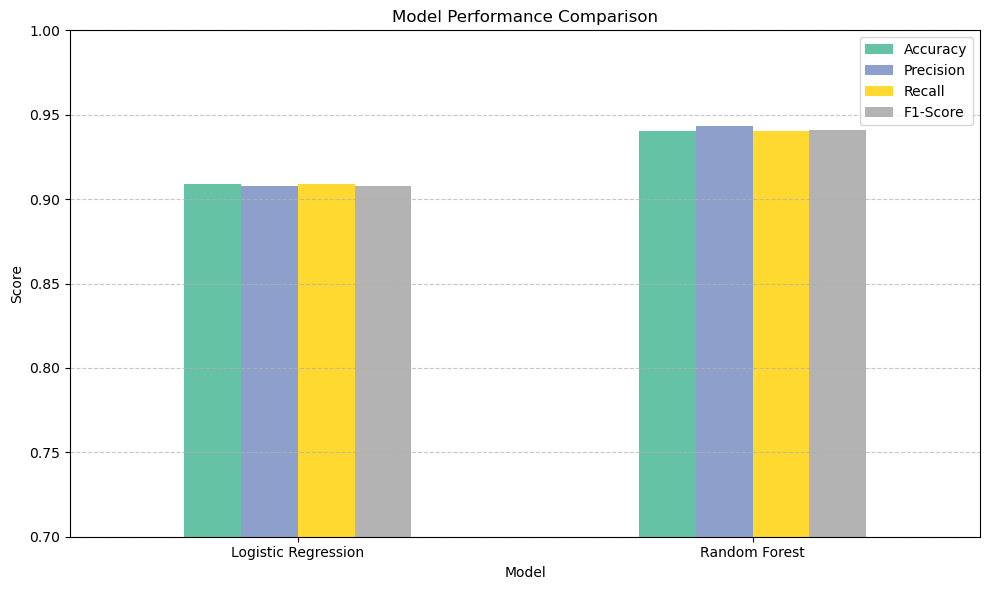

In [37]:
#visualize performance comparison
plt.figure(figsize=(8,5))
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind='bar', figsize=(10,6), colormap='Set2', rot=0)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.7, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### **Class Accuracy Comparison**
Let us now view a side-by-side view of per-class accuracy for each obesity level making it easy for us to see which classes each model predicts better.

In [38]:
#Linear Regression confusion matrix
cm_lr = np.array([[53,  0,  0,  0,  0,  0,  0],
                  [ 4, 46,  0,  0,  0,  5,  2],
                  [ 0,  0, 65,  3,  0,  0,  2],
                  [ 0,  0,  0, 60,  0,  0,  0],
                  [ 0,  0,  0,  1, 64,  0,  0],
                  [ 0,  6,  0,  0,  0, 46,  3],
                  [ 0,  3,  5,  0,  0,  4, 46]])

#Random Forest Classifier confusion matrix
cm_rf = np.array([[50,  3,  0,  0,  0,  0,  0],
                  [ 0, 53,  0,  0,  0,  3,  1],
                  [ 0,  0, 67,  0,  0,  1,  2],
                  [ 0,  0,  0, 60,  0,  0,  0],
                  [ 0,  0,  0,  1, 64,  0,  0],
                  [ 0,  7,  0,  0,  0, 46,  2],
                  [ 0,  2,  0,  0,  0,  3, 53]])

class_names = ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 
               'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 
               'Overweight_Level_II']

#calculate per-class accuracy
accuracy_lr = cm_lr.diagonal() / cm_lr.sum(axis=1)
accuracy_rf = cm_rf.diagonal() / cm_rf.sum(axis=1)

#results
print(f"{'Class':30s} {'Logistic Regression':>20s} {'Random Forest':>15s}")
for cls, acc_lr, acc_rf in zip(class_names, accuracy_lr, accuracy_rf):
    print(f"{cls:30s} {acc_lr*100:20.2f}% {acc_rf*100:15.2f}%")


Class                           Logistic Regression   Random Forest
Insufficient_Weight                          100.00%           94.34%
Normal_Weight                                 80.70%           92.98%
Obesity_Type_I                                92.86%           95.71%
Obesity_Type_II                              100.00%          100.00%
Obesity_Type_III                              98.46%           98.46%
Overweight_Level_I                            83.64%           83.64%
Overweight_Level_II                           79.31%           91.38%


### **Compare Training Vs Test Accuracy**
Let us now compare training and test accuracies for both models to assess generalization.

In [39]:
#evaluate training accuracy
train_acc_lr = log_reg.score(X_train_fs, y_train)
test_acc_lr = log_reg.score(X_test_fs, y_test)

train_acc_rf = rf.score(X_train_fs, y_train)
test_acc_rf = rf.score(X_test_fs, y_test)

print("Logistic Regression - Training Accuracy:", train_acc_lr)
print("Logistic Regression - Test Accuracy:", test_acc_lr)

print("Random Forest - Training Accuracy:", train_acc_rf)
print("Random Forest - Test Accuracy:", test_acc_rf)

Logistic Regression - Training Accuracy: 0.9131216297183943
Logistic Regression - Test Accuracy: 0.9090909090909091
Random Forest - Training Accuracy: 1.0
Random Forest - Test Accuracy: 0.9401913875598086


#### **Result Interpretation**
Logistic Regression achieves a training accuracy of 91.31% and a test accuracy of 90.91%, indicating consistent performance while Random Forest achieves a perfect training accuracy of 100% and a test accuracy of 94.02%, showing strong learning of the training data.

## **Hyperparameter Tuning**
Let us perform hyperparameter tuning to optimize the performance of our models.

### **Logistic Regression**

In [40]:
from sklearn.model_selection import GridSearchCV

#define parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'sag', 'saga', 'newton-cg'],
    'max_iter': [500, 1000]
}

#initialize model
log_reg = LogisticRegression(multi_class='multinomial', random_state=42)

#grid search with 5-fold cross-validation
grid_lr = GridSearchCV(estimator=log_reg, param_grid=param_grid_lr,
                       cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

grid_lr.fit(X_train_fs, y_train)

print("Best Parameters for Logistic Regression:", grid_lr.best_params_)
print("Best Cross-Validation Accuracy:", grid_lr.best_score_)


Fitting 5 folds for each of 32 candidates, totalling 160 fits


C:\Users\HP 1040 X360 G5\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best Parameters for Logistic Regression: {'C': 10, 'max_iter': 500, 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.9388861915808023


The results show that the best parameters are C = 10, max_iter = 500 and solver = 'lbfgs'. These settings yield the highest cross-validation accuracy of 93.9%, indicating that this configuration allows the model to generalize well on unseen data.

### **Random Forest Classifier**

In [41]:
#define parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

#initialize Random Forest model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

#grid search with 5-fold cross-validation
grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf,
                       cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

#fit to training data
grid_rf.fit(X_train_fs, y_train)

#display best parameters and best CV accuracy
print("Best Parameters for Random Forest:", grid_rf.best_params_)
print("Best Cross-Validation Accuracy:", grid_rf.best_score_)


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters for Random Forest: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best Cross-Validation Accuracy: 0.9556652460844077


The best parameters identified are n_estimators = 300, max_depth = None, max_features = None, min_samples_split = 2 and min_samples_leaf = 1.

Using these settings, the Random Forest achieved a best cross-validation accuracy of 95.6%, demonstrating strong generalization and high predictive capability for classifying obesity levels.

## **Evaluation of the Output**
The classification models, Logistic Regression and Random Forest, both perform well, with Random Forest achieving superior metrics across accuracy, precision, recall and F1-score. This indicates that the model reliably predicts the obesity level of individuals across all categories. The confusion matrices show that most misclassifications occur between adjacent obesity levels, which is understandable given the gradual nature of weight categories. 

Overall, the Random Forest model demonstrates strong generalization and minimal bias, making it robust for real-world applications.

### **Business Insights**
The insights gained from this classification task can help businesses make data-driven decisions:
- *Personalized Health Recommendations:* By accurately predicting obesity levels, nutritionists and wellness programs can design personalized meal plans and physical activity regimens for individuals.
- *Targeted Interventions:* Healthcare providers can prioritize resources for high-risk groups, potentially preventing obesity-related complications.
- *Policy and Awareness Campaigns:* Organizations can identify demographic trends, such as age groups more prone to obesity and design targeted public health campaigns.

### **Actionable Recommendations**
- *Implement Screening Programs:* Use the Random Forest model as a predictive tool in clinics and health apps to screen individuals for obesity risk.
- *Monitor Lifestyle Interventions:* Track changes in individuals’ obesity levels over time to assess the effectiveness of nutrition and fitness programs.
- *Integrate with Employee Wellness Programs:* Companies can incorporate predictions into wellness initiatives to promote healthier lifestyles and reduce medical costs.

## **Conclusion**
The study successfully demonstrates that both models particularly Random Forest can accurately classify obesity levels based on lifestyle, dietary and physical characteristics. The models provide actionable insights that can guide personalized interventions, resource allocation and public health strategies. By applying these methods an organization can improve decision-making, enhance preventive healthcare and ultimately support healthier communities.